# Comparison of TriTime2d with Eik2d and PL : Classic Two Layer Case

In [10]:
# systems operations
import os

# math
import numpy as np

# track time of process
import time

# meshing
import gmsh

# for calling Eik2d and PL
import ctypes

# graphics
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# set default font size in plots
plt.rcParams.update({'font.size': 20})
%matplotlib inline

# plotting violin plots 
import pandas as pd 
import seaborn as sns

## Importing local scripts and libraries into notebook
Mark Noble's Eik2d can be downloaded from [here](https://github.com/Mark-Noble/FTeik-Eikonal-Solver). Podvin and Lecomtes code, referred to henceforth as PL needs to be compiled in C first. 

In [ ]:
# import Eik2d 
import eik2d   # only works with python 3.12 if you specify inclusion of the directory where you are compiling  

In [13]:
# PL solver
so_file = r"PL/time_2d.so"    # provide path to the .so file that you have compiled, otherwise comment this cell out 
time_so = ctypes.CDLL(so_file)
time_2d = time_so.time_2d


In [4]:
%reload_ext autoreload
%autoreload 2
import tritime2d as tt


## Input parameters
**v1** : velocity in first layer 

**v2** : velocity in second layer 

**sx**,**sz** : position of source

**bx**,**bz** : width and depth of computational domain 

**layer_depth** : depth to layer 

**nx,nz** : number of nodes in x and z direction where the traveltime is calculated
            velocity has the same array for use in Podvin and Noble's code
**lcar** : mesh spacing at boundaries 

**lay_car** : mesh spacing along boundary of layer

**scar** : mesh spacing at source

The source depth must be inside the computational area (i.e. 0 < sx < bx & 0 < sz < bz) as should the layer (i.e. 0 < layer_depth < bz )

In [5]:
v1 = 1000;
v2 = 3000;

layer_depth = 3000.0

z0_1 = 0. 
z0_2 = 0.

vgrad_1 = 0. 
vgrad_2 = 0.


sx = 5000.0 
sz = 1500.0 

bx = 10000.0 
bz = 5000.0


lcar = 100. #100.0
lay_car = 100. #50. #25. 
scar = 100. # 100. #10.0

dx = lcar
dz = lcar 

nx = int(bx/lcar)+1
nz = int(bz/lcar)+1
nl = int(layer_depth/lcar)

vel = np.zeros((nz,nx))
vel[:,:]=v1
vel[nl:nz,:]=v2

In [6]:
gmsh.initialize()
gmsh.model.add("Two Layer Model")

In [ ]:

nlayers = 2

v = np.append(v1,v2)
layer_v = np.append(v1,v2)
vgrad = np.append(vgrad_1 ,  vgrad_2)
Grad_z0 = np.append(z0_1 , z0_2)

# add points
p2 = gmsh.model.geo.addPoint( 0,    0, 0, lcar, 1)
p3 = gmsh.model.geo.addPoint(bx,    0, 0, lcar, 2)
p4 = gmsh.model.geo.addPoint(bx,  layer_depth, 0, lay_car, 3)
p5 = gmsh.model.geo.addPoint(bx, bz, 0, lcar, 4)
p6 = gmsh.model.geo.addPoint( 0.0, bz, 0, lcar, 5)
p7 = gmsh.model.geo.addPoint( 0.0,  layer_depth, 0, lay_car, 6)

# s1 = gmsh.model.geo.addPoint( sx,  sz, 0, lay_car, 7)
s1 = gmsh.model.geo.addPoint( sx,  sz, 0, scar, 7)
# add lines

l23 = gmsh.model.geo.addLine(p2, p3, 23)
l34 = gmsh.model.geo.addLine(p3, p4, 34)
l45 = gmsh.model.geo.addLine(p4, p5, 45)
l56 = gmsh.model.geo.addLine(p5, p6, 56)
l67 = gmsh.model.geo.addLine(p6, p7, 67)
l72 = gmsh.model.geo.addLine(p7, p2, 72)
l74 = gmsh.model.geo.addLine(p7, p4, 74)


# curve loop
gmsh.model.geo.addCurveLoop([l23, l34, -l74, l72], 1)
gmsh.model.geo.addCurveLoop([l45, l56, l67, l74], 2)

# loop over surfaces to be added  
for l in range(1, 3):
    gmsh.model.geo.addPlaneSurface([l], l)

# synchronize before adding point
gmsh.model.geo.synchronize()

if (sz < layer_depth):
    gmsh.model.mesh.embed(0, [7], 2, 1) # embed a point 7 (dim 0) which is node 1 in a surface (i.e. dim 2) entitled 1 
else:
    gmsh.model.mesh.embed(0, [7], 2, 2) # embed a point 7 (dim 0) which is node 1 in a surface (i.e. dim 2) entitled 2 

# give the surfaces physical values 
for l in range(1, nlayers):
    gmsh.model.addPhysicalGroup(2,[l],l)    

# gmsh.option.setNumber("Mesh.Algorithm", 8)

# Set algorithm for irregular mesh
gmsh.option.setNumber("Mesh.Algorithm", 5)  # Delaunay
gmsh.option.setNumber("Mesh.RandomFactor", 1e-9)
gmsh.option.setNumber("Mesh.Smoothing", 100)

mesh = gmsh.model.mesh.generate(2)   # put as 2 as we are generating a 2d mesh 


# write mesh to file 
#gmsh.write("test.vtk")

# Clear existing model
#gmsh.finalize()   # doing this will mean that you lose the mesh

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 23 (Line)
Info    : [ 20%] Meshing curve 34 (Line)
Info    : [ 30%] Meshing curve 45 (Line)
Info    : [ 50%] Meshing curve 56 (Line)
Info    : [ 60%] Meshing curve 67 (Line)
Info    : [ 80%] Meshing curve 72 (Line)
Info    : [ 90%] Meshing curve 74 (Line)
Info    : Done meshing 1D (Wall 0.000794573s, CPU 0.001228s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 4.58609s, CPU 4.58793s)
Info    : 6664 nodes 13433 elements
Info    : Writing 'test.vtk'...
Info    : Done writing 'test.vtk'


### Extract the Nodes and Elements from the mesh


In [9]:
x, y, z, cells, cell_type = tt.extract_mesh()

In [10]:
cell_vel =  tt.velocity_by_layer(cell_type, layer_v)

### Calculate Theoretical Traveltimes

In [11]:
infinity = 10**20
ddx = 1

theta_c  = np.arcsin(v1/v2)
theo_time = np.zeros(len(y))

for i in range(len(y)):
    if y[i] <= layer_depth:           
        # direct wave
        theo_time[i] = np.sqrt((x[i]-sx)**2+(y[i]-sz)**2)/v1
        # conic wave
        x1 = (layer_depth-sz)*np.tan(theta_c)
        x2 = (layer_depth-y[i])*np.tan(theta_c)
        if np.abs(x[i]-sx) > x1+x2:
            conic_time = (2*layer_depth-sz-y[i])/v1/np.cos(theta_c)+(np.abs(x[i]-sx)-x1-x2)/v2
            if conic_time < theo_time[i]:
                theo_time[i] = conic_time                                   
    else:
            # refracted wave
        x_cross = 0
        tmin = np.sqrt((x[i]-sx)**2+(y[i]-layer_depth)**2)/v2+(layer_depth-sz)/v1
        not_found = True
        while (not_found):
            x_cross = x_cross+ddx
            t_test = np.sqrt((np.abs(x[i]-sx)-x_cross)**2+(y[i]-layer_depth)**2)/v2+ np.sqrt(x_cross**2+(layer_depth-sz)**2)/v1
            if t_test < tmin :
                tmin = t_test
            else:
                not_found = False
        theo_time[i] = tmin

## Assign initial travel time 
**Note:** If doing this manually, set non-source nodes to 1.e32 to get fastest computational times

In [12]:
initial_time = tt.init_traveltime(sx, sz, x, y, cells, cell_vel)

Source location [5000.0, 1500.0], source is in cell 1275
Initial travel time on starting cell: [0.11153042 0.         0.08612546]
Source located at a single node


## Set diffraction points 
All nodes within 5m of the interface are set as diffraction points

In [13]:
diff_zone = 5.
# set diffraction nodes 
diff_nodes = np.zeros(len(x))
for i in range(len(x)):
    if (np.abs(y[i]- layer_depth) < diff_zone):
        diff_nodes[i] = 1

### Plot input model and analytical solution  
We plot the mesh, the defined diffraction points and source location. Contours of the analytical solution are plotted as contours 

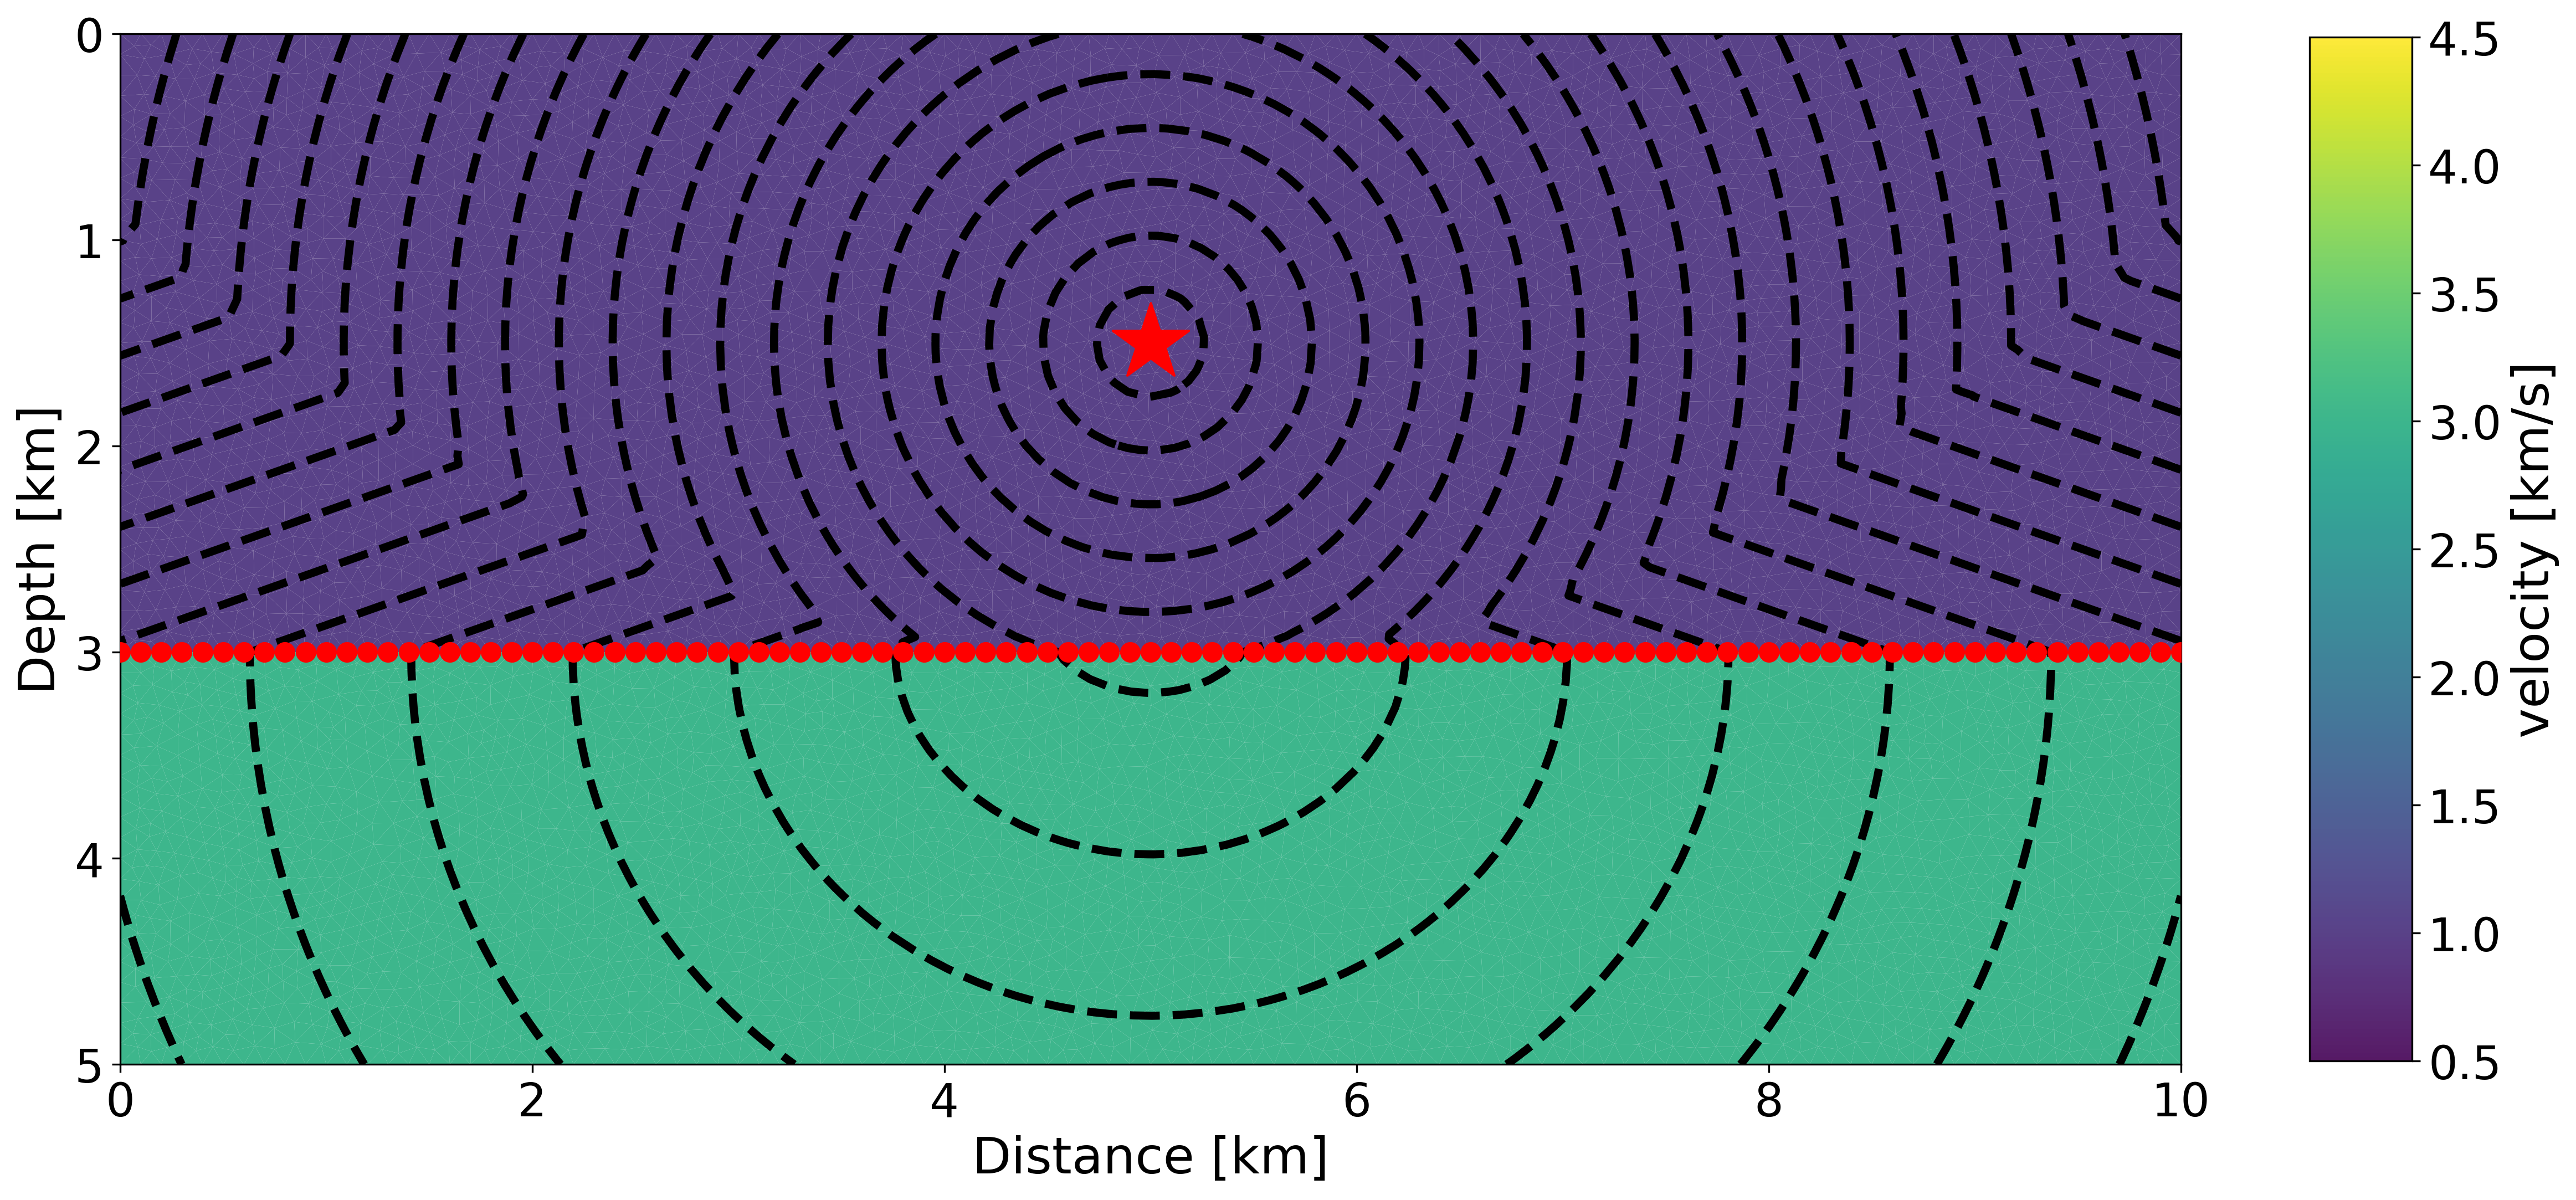

In [14]:
kilo = 1000 

patches = []
for i in range(len(cells)):
    idx = cells[i]
    poly_pts = np.transpose(np.vstack((x[idx]/kilo,y[idx]/kilo)))
    polygon = Polygon(poly_pts)
    patches.append(polygon)


fig, ax = plt.subplots(figsize=(20,20), dpi=300)  
p = PatchCollection(patches, alpha=0.9,edgecolor='none', cmap='viridis')
p.set_array(cell_vel/kilo)
p.set_clim(vmin=0.5, vmax=4.5)  # Set your desired min/max values here

ax.add_collection(p)
plt.scatter(sx/kilo, sz/kilo, c='red', s=1200, marker='*', label='Source',zorder=2, clip_on=False)

max_time = max(theo_time)
min_time = min(theo_time)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )

# plot figure 
tcf_tri = plt.tricontour(x/kilo, y/kilo, theo_time,levels = levels, colors='k',linestyles='--',linewidths=3.5)

mask = diff_nodes > 0
if mask.any():
    plt.scatter(x[mask]/kilo, y[mask]/kilo, s=250, c='r', marker='.', zorder=5, label='Diffraction nodes')

cbar = fig.colorbar(p, ax=ax,shrink=0.4, aspect=10, pad=0.05)
cbar.set_label('velocity [km/s]',fontsize=22)

plt.xlim(np.min(x/kilo),np.max(x/kilo)) 
plt.ylim(np.max(y/kilo),np.min(y/kilo)) # flip axis for depth
ax.set_aspect('equal')

ax.set_xlabel(r'Distance [km]',fontsize=22)
ax.set_ylabel(r'Depth [km]',fontsize=22)

plt.show()

In [16]:
print('In TriTime2d, no. of cells:', len(cell_vel), ' no. of nodes:', len(x))

In TriTime2d, no. of cells: 13026  no. of nodes: 6664


## Run TriTime2d

In [17]:
start=time.time()
traveltime = tt.tritime2d(x, y, z, cells, cell_vel, initial_time, diff_nodes, fast=True)
end=time.time()
print(end-start)

 starting trilateration.....
0.021979093551635742


## Calculate error in traveltimes

In [18]:
mask = theo_time > 0.

safe_time = np.where(mask, theo_time, 1.)  # replace 0s with 1 to avoid divide-by-zero
Tri_Theo_diff = np.where(mask, (traveltime - theo_time) / safe_time * 100, 0.)

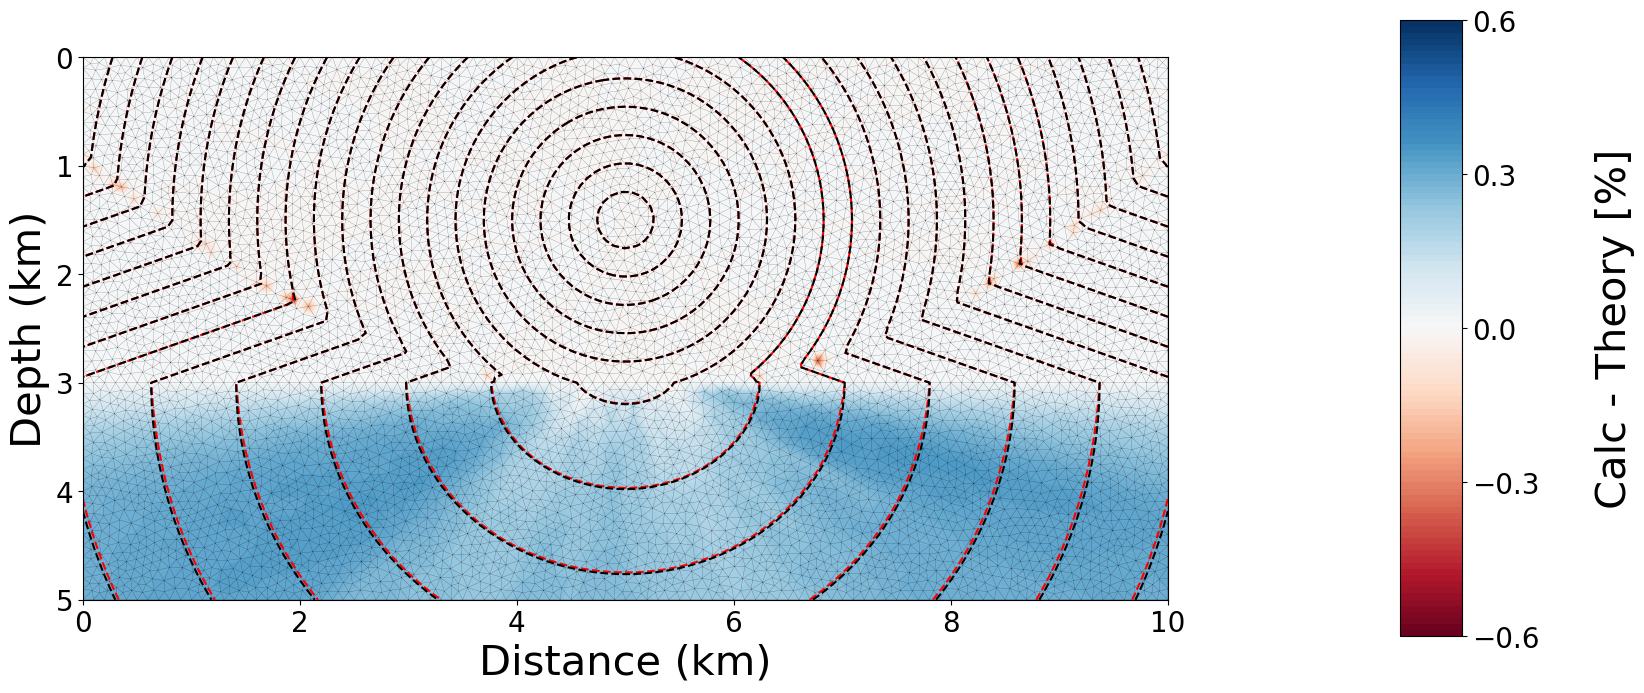

In [19]:
kilo = 1000. 
# c_range = np.max(np.max((abs(np.max(Tri_Theo_diff)),abs(np.min(Tri_Theo_diff)))))
c_range = 0.6

dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )

max_time = max(traveltime)
min_time = min(traveltime)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )


# plot figure 
fig = plt.figure(figsize=(20,20))
ax1 = plt.axes()
ax1.set_aspect('equal')

plt.triplot(x/kilo, y/kilo, cells, color='black', linewidth=0.1, zorder=2)
tcf_tri  = plt.tricontour( x/kilo, y/kilo, traveltime, levels=levels, colors='r', linestyles='--', zorder=2)
tcf_theo = plt.tricontour( x/kilo, y/kilo, theo_time,  levels=levels, colors='k', linestyles='--', zorder=2)
cc       = plt.tricontourf(x/kilo, y/kilo, Tri_Theo_diff, clevels, cmap='RdBu', zorder=1)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Distance (km)',fontsize=30)
plt.ylabel('Depth (km)',fontsize=30)

# Color bar
tt = np.linspace(-c_range, c_range, 5, endpoint=True)
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.15,ticks=tt)
cb.ax.tick_params(axis='both', which='major', labelsize=20)
cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)
ax1.invert_yaxis()


# fig.tight_layout()
plt.show()

Plot error distribution

In [20]:
print('error range:    ',np.max(Tri_Theo_diff),np.min(Tri_Theo_diff) ,'%')

error range:     0.3473113652642956 -0.5204284994069701 %


In [21]:

# Create categories
categories = (['TriTime'] * len(Tri_Theo_diff))

# Combine the data
values = np.concatenate([Tri_Theo_diff])

# Create the DataFrame
df = pd.DataFrame({'Solver': categories, 'Error': values})

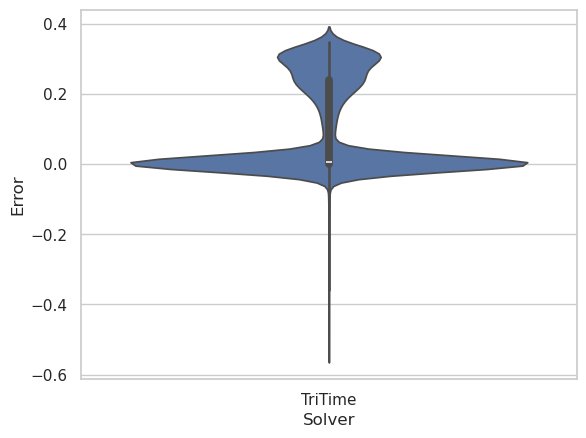

In [22]:
sns.set_theme(style="whitegrid")
ax = sns.violinplot(x="Solver", y="Error",data=df, hue="Solver",legend=False)

Write out results in a vtk file that can be read by paraview

In [ ]:
write_vtk(x, y, z, cells, cell_vel, traveltime, "TwoLayer_Case.vtk")

# Run Eik2d

In [ ]:
eps=10 ; n_sweep=4
slow=1./vel
# call 2d Eokonal and print elapsed time
start=time.time()
Noble_time = eik2d.fteik2d(slow,sz,sx,dz,dx,eps,n_sweep,nz,nx)
# Noble_time = eik2d.fteik2d(slow,sz,sx,dz,dx,n_sweep,nz,nx)     # note: new code does not require setting eps 
end=time.time()
print(end-start)

0.002463102340698242


In [28]:
print('Eik2d, no of cells:', (nz-1)*(nx-1), ' no. of nodes:', nx*nz)

Eik2d, no of cells: 5000  no. of nodes: 5151


## Run PL 

In [29]:
infinity = 10**20
dx =100.

time_2d.argtypes = [POINTER(c_double), POINTER(c_double), c_int, c_int, c_double,c_double, c_double, c_int] # specify c types argument for the function
myVecType = nx*nz*c_double
pltime = myVecType()
pod_slow = myVecType()

# define slowness and time array
for i in range(0,nx*nz):
    pod_slow[i] = 0.0 
    pltime[i] = infinity

ii = 0
for i in range(0,nz):
    for j in range(0,nx):
        pod_slow[ii] = dx/vel[i,j]
        ii = ii+1

In [30]:
pod_sz = int(sz/dx)
pod_sx = int(sx/dx)
eps = 0.001
start=time.time()

pod_out = time_2d(pod_slow,pltime,nz,nx,pod_sz,pod_sx,eps,0)
end=time.time()
print(end-start)
pod_time = np.reshape(pltime,(nz,nx))

0.0004553794860839844


### Compare PL and Eik2d with theoretical value 
- this needs to be done differently to TriTime as these codes use grids as opposed to irregular meshes 

In [31]:
z_array = np.arange(0, dz*nz, dz)
x_array = np.arange(0, dx*nx, dx)
cart_X, cart_Z = np.meshgrid(x_array,z_array)


infinity = 10**20
ddx = 1
theta_c  = np.arcsin(v1/v2)
cart_theo_time = np.zeros((nz,nx))
for i in range(0,nz):
    for j in range(0,nx):
        if cart_Z[i,j] <= layer_depth:
            # direct wave
            cart_theo_time[i,j] = np.sqrt((cart_X[i,j]-sx)**2+(cart_Z[i,j]-sz)**2)/v1
            # conic wave
            x1 = (layer_depth-sz)*np.tan(theta_c)
            x2 = (layer_depth-cart_Z[i,j])*np.tan(theta_c)
            if np.abs(cart_X[i,j]-sx) > x1+x2:
                conic_time = (2*layer_depth-sz-cart_Z[i,j])/v1/np.cos(theta_c)+(np.abs(cart_X[i,j]-sx)-x1-x2)/v2
                if conic_time < cart_theo_time[i,j]:
                    cart_theo_time[i,j] = conic_time 
                                    
        else:
            # refracted wave
            x_cross = 0
            tmin = np.sqrt((cart_X[i,j]-sx)**2+(cart_Z[i,j]-layer_depth)**2)/v2+(layer_depth-sz)/v1
            not_found = True
            while (not_found):
                x_cross = x_cross+ddx
                t_test = np.sqrt((np.abs(cart_X[i,j]-sx)-x_cross)**2+(cart_Z[i,j]-layer_depth)**2)/v2+ np.sqrt(x_cross**2+(layer_depth-sz)**2)/v1
                if t_test < tmin :
                    tmin = t_test
                else:
                    not_found = False
            cart_theo_time[i,j] = tmin

In [32]:
Tri_Theo_diff = np.zeros(len(Z))
for i in range(0,len(Z)):
        Tri_Theo_diff[i] = tri_time[i]-theo_time[i]
        if np.abs(Tri_Theo_diff[i]) <= 0. :
                Tri_Theo_diff[i] = 0. 
        else:
                Tri_Theo_diff[i] = Tri_Theo_diff[i]/theo_time[i]*100

In [33]:
n,m = np.shape(cart_X)
idx = np.zeros((n,m),dtype=int)
Eik_Theo_diff = np.zeros((n,m))
Pod_Theo_diff = np.zeros((n,m))


# Tri_Theo_diff_percent = np.zeros((n*m))
Eik_Theo_diff_percent = np.zeros((n,m))
Pod_Theo_diff_percent = np.zeros((n,m))

Tri_Theo_diff = np.zeros(len(Z))
Tri_Theo_diff_percent = np.zeros(len(Z))

for i in range(0,len(Z)):
        Tri_Theo_diff[i] = tri_time[i]-theo_time[i]
        if  (tri_time[i] > 0 ) :
            Tri_Theo_diff_percent[i] = Tri_Theo_diff[i]/theo_time[i]*100
        else :
            Tri_Theo_diff_percent[i] = 0. 

for i in range(0,n):
    for j in range(0,m):
        Eik_Theo_diff[i,j] = (Noble_time[i,j]- cart_theo_time[i,j])
        Pod_Theo_diff[i,j] = (pod_time[i,j]- cart_theo_time[i,j])        
        if ( cart_theo_time[i,j] > 0.) :
                    Eik_Theo_diff_percent[i,j] = Eik_Theo_diff[i,j]/ cart_theo_time[i,j]*100
                    Pod_Theo_diff_percent[i,j] = Pod_Theo_diff[i,j]/ cart_theo_time[i,j]*100
        else:
                    Eik_Theo_diff_percent[i,j] = 0.
                    Pod_Theo_diff_percent[i,j] = 0.

### Plot error associated with PL and Eik2d

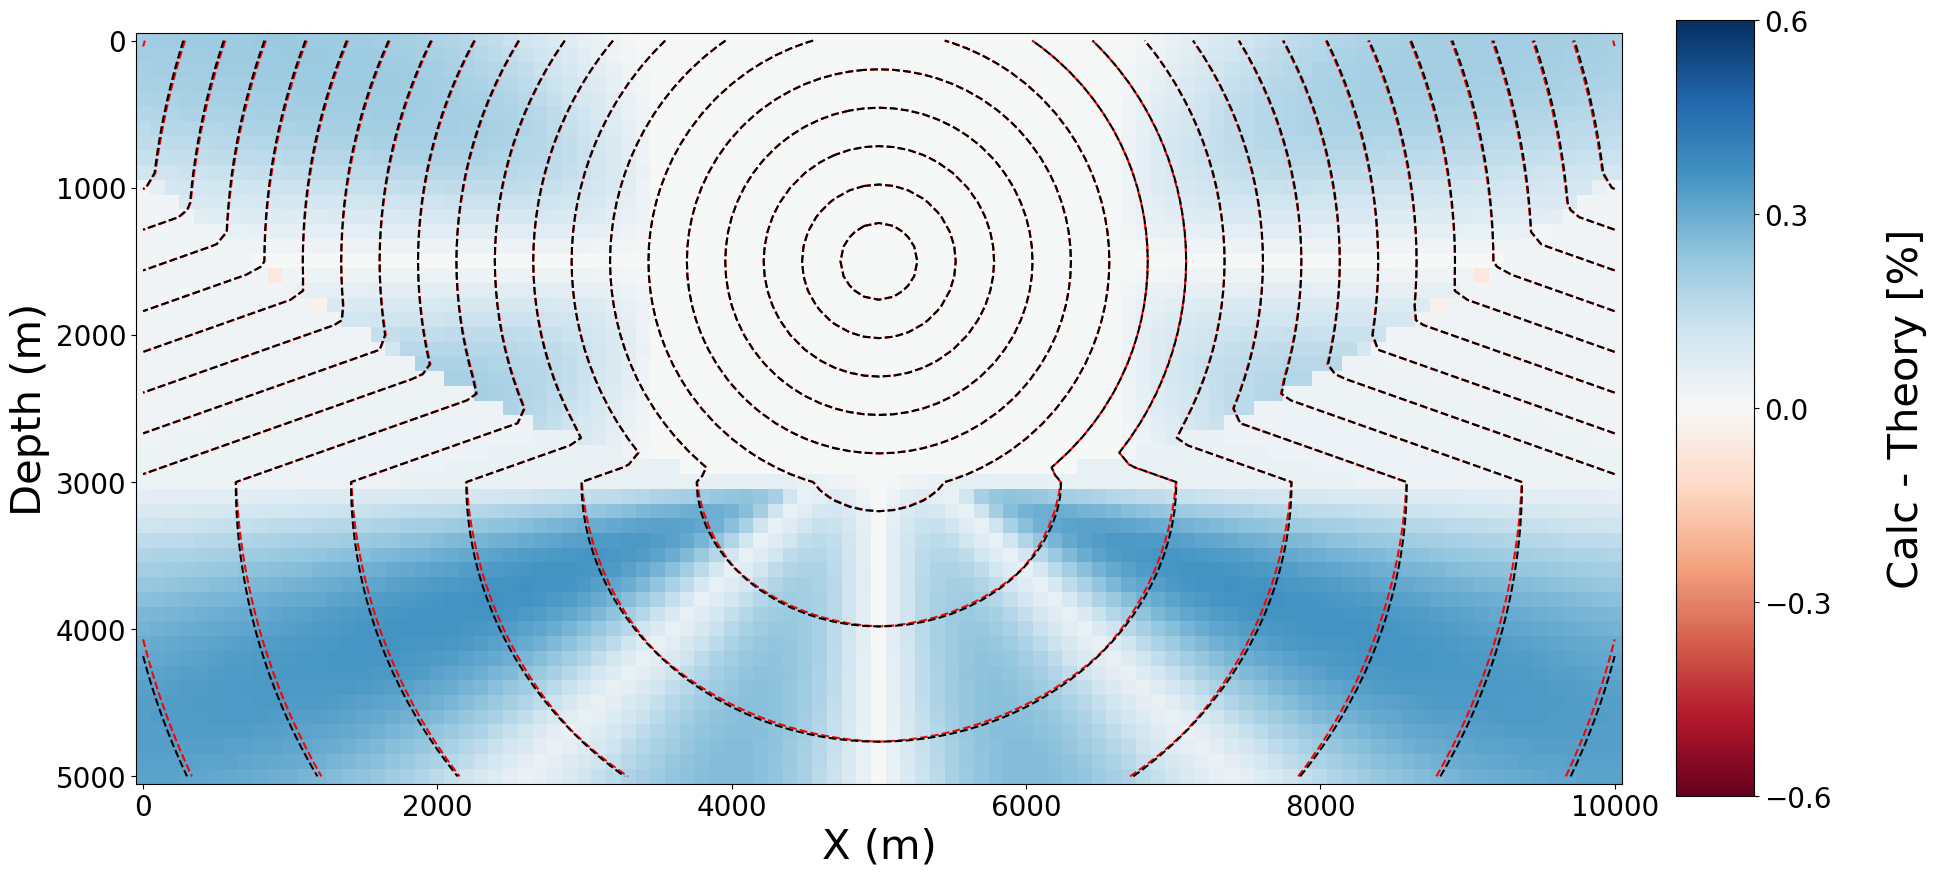

In [34]:
ncontours = 20
dc = (max(tri_time)-min(tri_time))/ncontours          # use tri lateration contours
levels = np.arange(min(tri_time), max(tri_time)+dc,dc )


# c_range = np.max(np.max((abs(np.max(Pod_Theo_diff_percent)),abs(np.min(Pod_Theo_diff_percent)))))
c_range = 0.6

dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )

fig = plt.figure(figsize=(20,20))
ax1 = plt.axes()
ax1.set_aspect('equal')
cc = ax1.pcolor(cart_X,cart_Z,Pod_Theo_diff_percent,vmin=-c_range,vmax=c_range,cmap ='RdBu' )#,vmin=0,vmax=400) 
plt.contour(cart_X,cart_Z,pod_time,levels = levels, colors='r',linestyles='--')
plt.contour(cart_X,cart_Z,cart_theo_time,levels = levels, colors='k',linestyles='--')

ax1.invert_yaxis()

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('X (m)',fontsize=30)
plt.ylabel('Depth (m)',fontsize=30)
#plt.title('Difference in Traveltimes: Tri V Eik', fontsize=30)
#Color bar
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.03)
# cb.ax.set_title('Calc - Theory [%]',fontsize=30)
cb.set_ticks([0.6, 0.3,0, -0.3, -0.6])

# cb.set_ticks([1, 0.75, 0.5, 0.25, 0, -0.25, -0.5, -0.75, -1])
cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)

cb.ax.tick_params(labelsize=20)
fig.tight_layout()
plt.show()

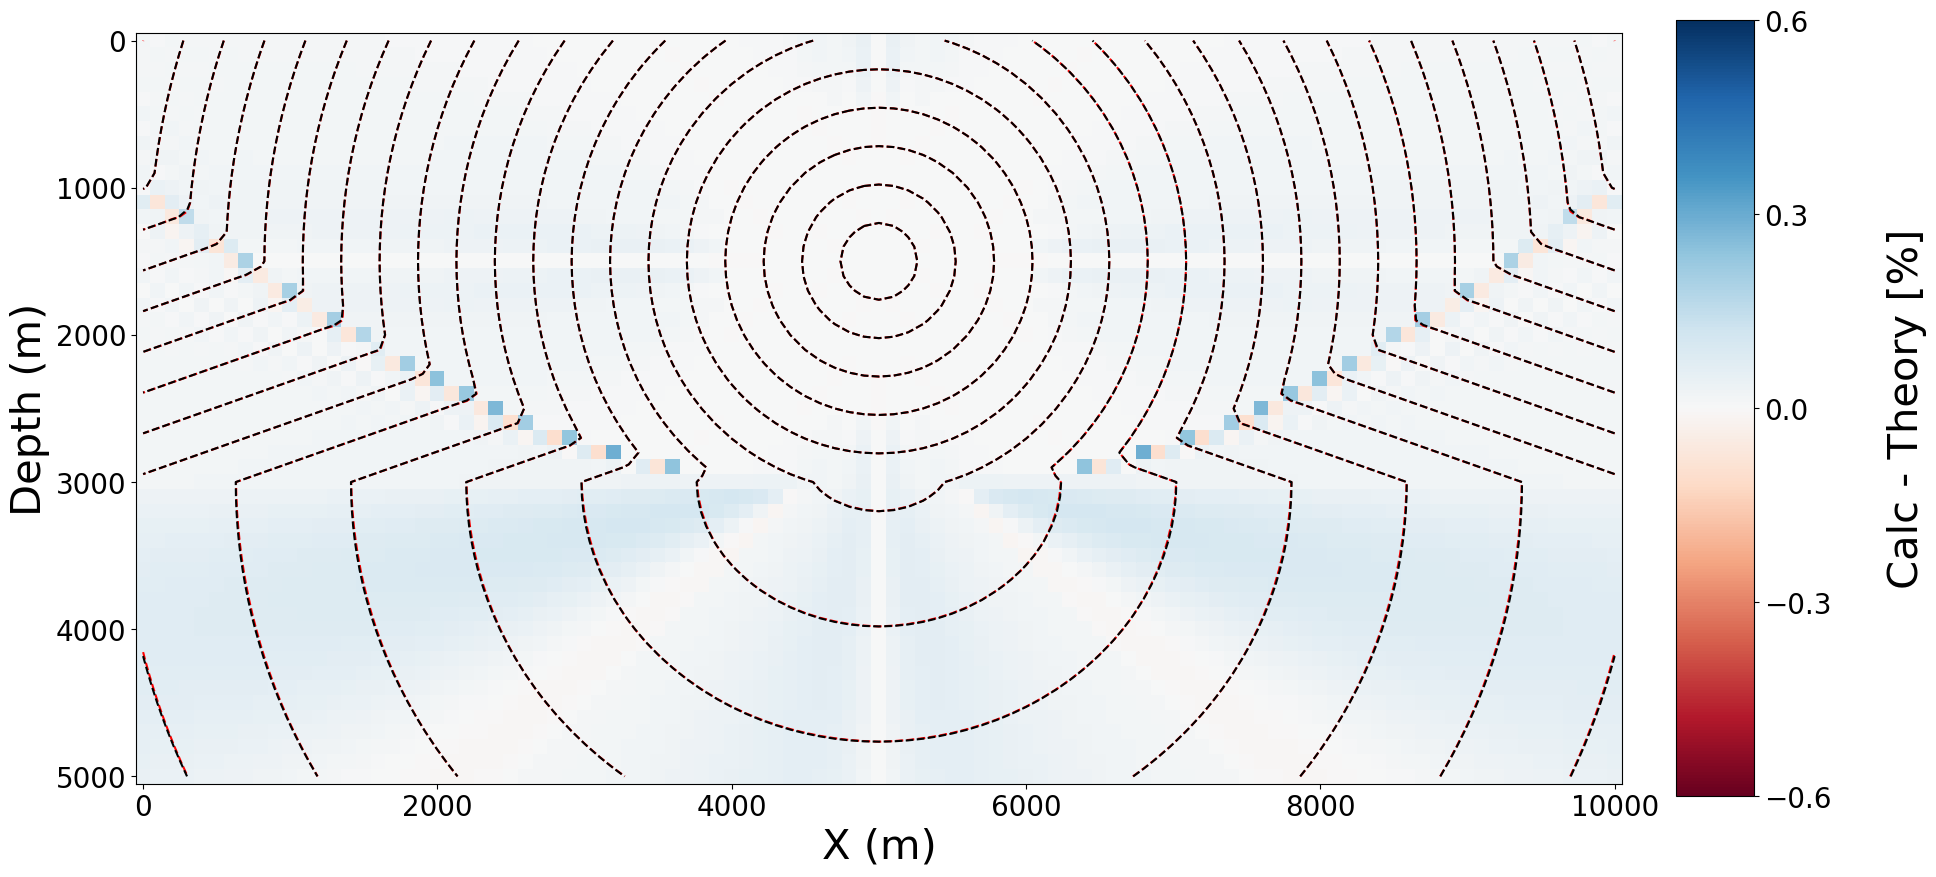

In [35]:
ncontours = 20
dc = (max(tri_time)-min(tri_time))/ncontours          # use tri lateration contours
levels = np.arange(min(tri_time), max(tri_time)+dc,dc )


# c_range = np.max(np.max((abs(np.max(Eik_Theo_diff_percent)),abs(np.min(Eik_Theo_diff_percent)))))
c_range = 0.6

dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )

fig = plt.figure(figsize=(20,20))
ax1 = plt.axes()
ax1.set_aspect('equal')
cc = ax1.pcolor(cart_X,cart_Z,Eik_Theo_diff_percent,vmin=-c_range,vmax=c_range,cmap ='RdBu' )#,vmin=0,vmax=400) 
plt.contour(cart_X,cart_Z,Noble_time,levels = levels, colors='r',linestyles='--')
plt.contour(cart_X,cart_Z,cart_theo_time,levels = levels, colors='k',linestyles='--')
# tcf_tri = plt.tricontour(X, Z, tri_time,levels = levels, colors='k',linestyles='--',zorder=1)

ax1.invert_yaxis()

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('X (m)',fontsize=30)
plt.ylabel('Depth (m)',fontsize=30)
#plt.title('Difference in Traveltimes: Tri V Eik', fontsize=30)
#Color bar
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.03)
# cb.ax.set_title('Tri - Theory [s]',fontsize=20)
# cb.ax.set_title('Calc - Theory [%]',fontsize=30)
# cb.set_ticks([1, 0.75, 0.5, 0.25, 0, -0.25, -0.5, -0.75, -1])
cb.set_ticks([0.6, 0.3,0, -0.3, -0.6])

cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)
cb.ax.tick_params(labelsize=20)
fig.tight_layout()
plt.show()

### Violin Plots

In [95]:
import pandas as pd 
import seaborn as sns

In [ ]:
# Create categories
categories = (['TriLat'] * len(Tri_Theo_diff_percent) + 
              ['Eik2d'] * len(np.ravel(Eik_Theo_diff_percent)) + 
              ['Podvin'] * len(np.ravel(Pod_Theo_diff_percent)))

# # Combine the data
values = np.concatenate([Tri_Theo_diff_percent, np.ravel(Eik_Theo_diff_percent), np.ravel(Pod_Theo_diff_percent)])

# Create the DataFrame
df = pd.DataFrame({'Category': categories, 'Error': values})

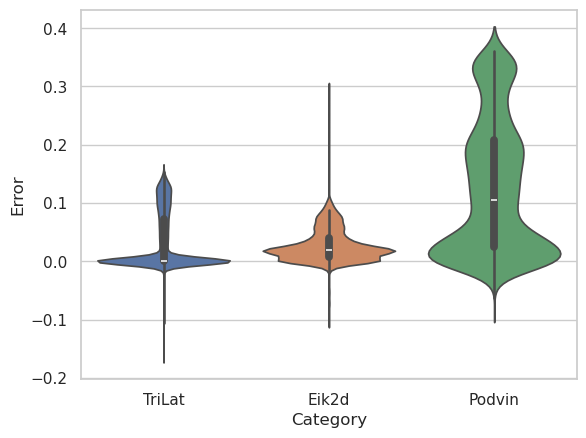

In [125]:
sns.set_theme(style="whitegrid")

ax = sns.violinplot(x="Category", y="Error",data=df, hue="Category",legend=False)
plt.show()

Write data to file

In [ ]:
# write dataframe to file 
df.to_csv(r'Two_Layer_error.csv')